In [29]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process
import importlib
from tqdm.auto import tqdm
import multiprocessing as mp
from scipy import stats 

### Run stats on human results 
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
from statsmodels.formula.api import ols


# Get human data 

In [36]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

In [37]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [ ]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

In [38]:
importlib.reload(util_process)

path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v02')

part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v02/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    part_name = result_file.stem
    part_ix = int(re.search(r'(\d+)', part_name).group())
    if part_ix > 33:
        continue
    if any(pilot_part_ix == part_ix for pilot_part_ix in [34, 35]):
        continue 

    # remove space 

    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    manifest_file = manifest_dict[part_name_str]
    part_df = util_process.get_part_df(result_file)
    manifest_df = util_process.get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name_str
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)

## add transcripts for scoring 
results_df['dist_1_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_1_fn.to_list()]
results_df['dist_2_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_2_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.src_fn.to_list()]

cols_to_score = ['response', 'target_word', 'distractor_1_word', 'distractor_2_word', 'target_transcripts', 'dist_1_transcripts', 'dist_2_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_1_word, distractor_2_word, target_transcripts, dist_1_transcripts, dist_2_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_1_transcripts or response in dist_2_transcripts or response in [distractor_1_word, distractor_2_word]))

results_df['correct'] = correct
results_df['confusions'] = confusions




In [39]:
results_df['participant_ix'] = results_df.participant.str.extract(r'(\d+)').astype(int)


In [88]:
results_df.columns

Index(['trial_num', 'response', 'correct_response', 'correct', 'target_loc',
       'distractor_loc', 'azim_delta', 'elev_delta', 'snr', 'target_word',
       'distractor_word', 'target_azim', 'target_elev', 'distractor_azim',
       'distractor_elev', 'n_distractors', 'distractor_1_word',
       'distractor_2_word', 'src_fn', 'distractor_1_fn', 'distractor_2_fn',
       'participant', 'dist_1_transcripts', 'dist_2_transcripts',
       'target_transcripts', 'confusions', 'participant_ix'],
      dtype='object')

In [40]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'azim_delta', #'sex_condition',
                                   'elev_delta', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]


part_perf_avg = grouped_part_results.groupby('participant').correct_mean.mean()
# filter bad participants as those performing below the lower bound (mean - 2 SEM) seen in the online experiments with the same stimuli
cutoff = 0.3
good_parts = part_perf_avg[(part_perf_avg > cutoff)].index

## Update. Right way to filter: Remove outliers. Compute average performance per participant and make histogram. 
### Make sure average across conditions meets certain threshold.

good_part_results = grouped_part_results[grouped_part_results.participant.isin(good_parts)]

print(f"{good_part_results.participant.nunique()} participants above {cutoff} cutoff (out of {part_perf_avg.shape[0]} total)")


33 participants above 0.3 cutoff (out of 33 total)


In [ ]:
### Get threshold values 

good_part_results.groupby()

,participant,target_azim,target_elev,azim_delta,elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,0,0,-9,2,0.1875,0.100778,0.1250,0.085391,16
1,participant_001,0,40,0,0,-6,2,0.2500,0.111803,0.1875,0.100778,16
2,participant_001,0,40,0,0,-3,2,0.3125,0.119678,0.2500,0.111803,16
3,participant_001,0,40,0,0,0,2,0.2500,0.111803,0.0625,0.062500,16
4,participant_001,0,40,0,0,3,2,0.7500,0.111803,0.0000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...
985,participant_033,0,40,60,0,-6,2,0.1875,0.100778,0.3125,0.119678,16
986,participant_033,0,40,60,0,-3,2,0.2500,0.111803,0.1250,0.085391,16
987,participant_033,0,40,60,0,0,2,0.3125,0.119678,0.0625,0.062500,16
988,participant_033,0,40,60,0,3,2,0.6250,0.125000,0.0625,0.062500,16


### Get thresholds 



In [84]:
good_part_results

,participant,target_azim,target_elev,azim_delta,elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,0,0,-9,2,0.1875,0.100778,0.1250,0.085391,16
1,participant_001,0,40,0,0,-6,2,0.2500,0.111803,0.1875,0.100778,16
2,participant_001,0,40,0,0,-3,2,0.3125,0.119678,0.2500,0.111803,16
3,participant_001,0,40,0,0,0,2,0.2500,0.111803,0.0625,0.062500,16
4,participant_001,0,40,0,0,3,2,0.7500,0.111803,0.0000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...
985,participant_033,0,40,60,0,-6,2,0.1875,0.100778,0.3125,0.119678,16
986,participant_033,0,40,60,0,-3,2,0.2500,0.111803,0.1250,0.085391,16
987,participant_033,0,40,60,0,0,2,0.3125,0.119678,0.0625,0.062500,16
988,participant_033,0,40,60,0,3,2,0.6250,0.125000,0.0625,0.062500,16


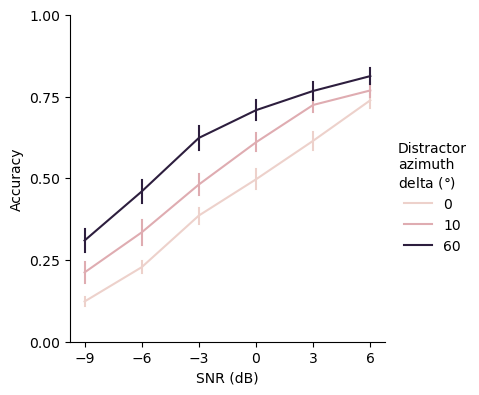

In [ ]:
part_summary = good_part_results.groupby(['participant', 'azim_delta', 'elev_delta', 'snr']).agg({'correct_mean':'mean', 'correct_sem':'mean'}).reset_index()

g = sns.relplot(data=part_summary[part_summary.elev_delta == 0],
            x='snr', y='correct_mean', hue='azim_delta', #col='elev_delta', 
                    errorbar=('se', 1),
                    err_style='bars',
                      height=4, aspect=1,
            kind='line',)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])

In [83]:
part_summary

,participant,azim_delta,elev_delta,snr,correct_mean,correct_sem
0,participant_001,0,0,-9,0.1875,0.100778
1,participant_001,0,0,-6,0.2500,0.111803
2,participant_001,0,0,-3,0.3125,0.119678
3,participant_001,0,0,0,0.2500,0.111803
4,participant_001,0,0,3,0.7500,0.111803
...,...,...,...,...,...,...
985,participant_033,60,0,-6,0.1875,0.100778
986,participant_033,60,0,-3,0.2500,0.111803
987,participant_033,60,0,0,0.3125,0.119678
988,participant_033,60,0,3,0.6250,0.125000


In [ ]:
import scipy 
import numpy as np 
from scipy.optimize import curve_fit
from numpy.polynomial import Polynomial

def fit_threshold_poly(snrs, prop_correct, degree=2):
    poly = Polynomial.fit(x=snrs, y=prop_correct, deg=degree)
    return poly

def get_dBSNR_threshold(poly, threshold=0.5, precision=1_000):
    snrs, prop_correct = poly.linspace(n=precision)
    dB_threshold = snrs[np.argwhere(prop_correct >=threshold).min()]
    return dB_threshold

def estimate_threshold_poly(snrs, prop_correct, degree=2, threshold=0.5):
    poly = fit_threshold_poly(snrs, prop_correct, degree)
    threshold = get_dBSNR_threshold(poly)
    return threshold, poly

degree = 2

azim_to_plot = part_summary[
                            (part_summary.elev_delta == 0) 
                                    ].copy()

elev_to_plot = part_summary[
                            (part_summary.azim_delta == 0) 
                                ].copy()


offsets = [0, 10, 60]
directions = ['azim', 'elev']
thresholds = []

for offset in offsets:
    for direction in directions:
        if direction == 'azim':
            to_plot = azim_to_plot
        else:
            to_plot = elev_to_plot
        to_fit = to_plot.groupby([f'{direction}_delta', 'snr']).correct_mean.mean().reset_index()
        to_fit = to_fit[to_fit[f'{direction}_delta'] == offset]
        threshold, poly = estimate_threshold_poly(to_fit.snr.values, to_fit.correct_mean.values, degree)
        thresh_record = {
            'offset': offset,
            'direction': direction,
            'threshold': threshold,
        }
        thresholds.append(thresh_record)

        print(f"Threshold at {offset} {direction} delta: {threshold}")

human_thresh_means = pd.DataFrame(thresholds)


# human_thresh_means

Threshold at 0 azim delta: 0.08408408408408441
Threshold at 0 elev delta: 0.08408408408408441
Threshold at 10 azim delta: -2.708708708708709
Threshold at 10 elev delta: -1.4474474474474475
Threshold at 60 azim delta: -5.471471471471471
Threshold at 60 elev delta: -1.6276276276276276


,offset,direction,threshold
0,0,azim,0.084084
1,0,elev,0.084084
2,10,azim,-2.708709
3,10,elev,-1.447447
4,60,azim,-5.471471
5,60,elev,-1.627628


In [89]:
## Save means for later
path_to_human_results = Path('final_results_dir')
out_name = path_to_human_results / "summary_2024_human_threshold_means.pdpkl"
human_thresh_means.to_pickle(out_name)

In [90]:
human_thresh_means

,offset,direction,threshold
0,0,azim,0.084084
1,0,elev,0.084084
2,10,azim,-2.708709
3,10,elev,-1.447447
4,60,azim,-5.471471
5,60,elev,-1.627628


# Load pre-computed human threshold data

In [30]:
path_to_human_results = Path('final_results_dir')

human_thresh_df = pd.read_pickle(path_to_human_results / 'summary_2024_human_threshold_results_avg_sex_cond.pdpkl')
human_thresh_df_per_sex = pd.read_pickle(path_to_human_results / 'summary_2024_human_threshold_results_split_by_sex_cond.pdpkl')

In [71]:
human_thresh_df.groupby(['azim_delta', 'elev_delta']).threshold.mean().reset_index()


,azim_delta,elev_delta,threshold
0,0,0,0.059140
1,0,10,-1.474366
2,0,60,-1.585866
3,10,0,-2.814872
4,60,0,-5.495252


##### Load human data for permutation test and stats 

In [32]:
# ### Fit ANOVA for thresholds 
# #### Melt human thresh df for anova 

# for_anova = human_thresh_df.melt(id_vars=['n_participants', "threshold"], value_vars=['azim_delta', 'elev_delta'], 
#                                  var_name='offset_dir', value_name='offset_size')


# thresh_lm =  ols('threshold ~ C(offset_size) * C(offset_dir)',
#                  data=for_anova).fit()
# table = sm.stats.anova_lm(thresh_lm, typ=2) 
# print(table)

In [ ]:
N = 33

In [49]:

human_thresh_df_summary = human_thresh_df.groupby(['elev_delta', 'azim_delta']).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_thresh_df_summary.columns = ['elev_delta', 'azim_delta', 'threshold', 'threshold_std']


human_thresh_df_summary_per_sex = human_thresh_df_per_sex.groupby(['elev_delta', 'azim_delta', 'sex_cond']).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_thresh_df_summary_per_sex.columns = ['elev_delta', 'azim_delta', 'sex_cond', 'threshold', 'threshold_std']


In [72]:
human_thresh_df_summary

,elev_delta,azim_delta,threshold,threshold_std
0,0,0,0.059140,0.486347
1,0,10,-2.814872,0.635813
2,0,60,-5.495252,0.640000
3,10,0,-1.474366,0.462032
4,60,0,-1.585866,0.504760


## Plot human thresholds

In [76]:
human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]


,elev_delta,azim_delta,threshold,threshold_std
0,0,0,0.059140,0.486347
1,0,10,-2.814872,0.635813
2,0,60,-5.495252,0.640000


In [77]:
human_thresh_means

,offset,direction,threshold
0,0,azim,0.084084
1,0,elev,0.084084
2,10,azim,-2.708709
3,10,elev,-1.447447
4,60,azim,-5.471471
5,60,elev,-1.627628


Text(0.5, 0.98, 'Huamn thresholds (N=33)')

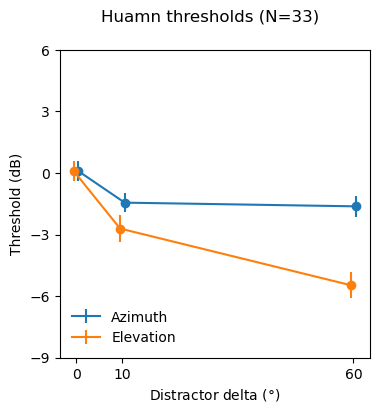

In [82]:
fig, ax = plt.subplots(1,1,figsize=(4,4))

azim_errors = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0].threshold_std.values
azim_means = human_thresh_means[human_thresh_means.direction == 'azim'].threshold.values

elev_errors = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0].threshold_std.values
elev_means = human_thresh_means[human_thresh_means.direction == 'elev'].threshold.values

offsets = human_thresh_means.offset.unique()

ax.errorbar(x=offsets + 0.5, y=elev_means, yerr=elev_errors, fmt='o-', label='Azimuth')
ax.errorbar(x=offsets - 0.5, y=azim_means, yerr=azim_errors, fmt='o-', label='Elevation')

ax.legend(loc='lower left', markerscale=0)
ax.get_legend().get_frame().set_linewidth(0.0)

ax.set_xlabel('Distractor delta ($\degree$)')
ax.set_ylabel('Threshold (dB)')
ax.set_xticks([0, 10, 60])
ax.set_yticks(np.arange(-9, 7, 3))


plt.suptitle(f"Huamn thresholds (N={N})",)

Text(0.5, 1.05, 'Huamn thresholds (N=33)')

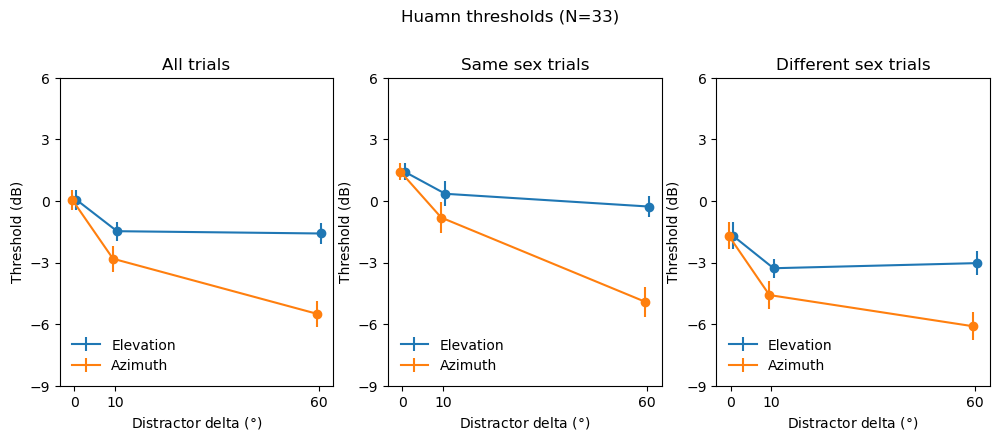

In [13]:
#### Per sex 
fig, ax = plt.subplots(1,3,figsize=(12,4))


sex_conds = ['all', 'same', 'different']
for ix, sex_cond in enumerate(sex_conds):
    if ix == 0:
        elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
        azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
        elev_to_plot = elev_data
        azim_to_plot = azim_data
    else: 
        elev_data = human_thresh_df_summary_per_sex[human_thresh_df_summary_per_sex.azim_delta == 0]
        azim_data = human_thresh_df_summary_per_sex[human_thresh_df_summary_per_sex.elev_delta == 0]
        elev_to_plot = elev_data[elev_data.sex_cond == sex_cond]
        azim_to_plot = azim_data[azim_data.sex_cond == sex_cond]

    ax[ix].errorbar(data=elev_to_plot, x=elev_to_plot.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Elevation')
    ax[ix].errorbar(data=azim_to_plot, x=azim_to_plot.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Azimuth')

    ax[ix].legend(loc='lower left', markerscale=0)
    ax[ix].get_legend().get_frame().set_linewidth(0.0)

    ax[ix].set_xlabel('Distractor delta ($\degree$)')
    ax[ix].set_ylabel('Threshold (dB)')
    ax[ix].set_xticks([0, 10, 60])
    ax[ix].set_yticks(np.arange(-9, 7, 3))
    if ix == 0:
        ax[ix].set_title("All trials")
    else:
        ax[ix].set_title(f"{sex_cond.title()} sex trials")

plt.suptitle(f"Huamn thresholds (N={N})", y=1.05)